0.4714440992428962
0.4865872633057824
-16.46609876420477


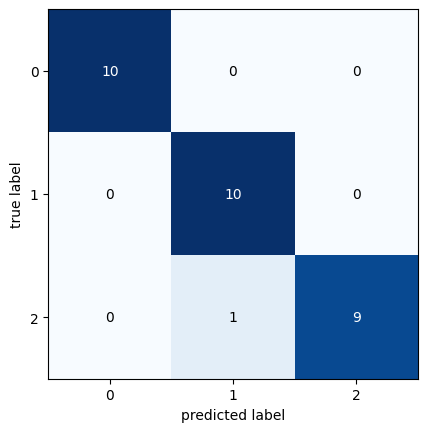

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.91      1.00      0.95        10
           2       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



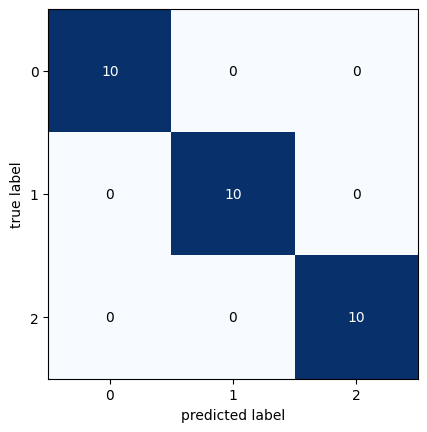

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



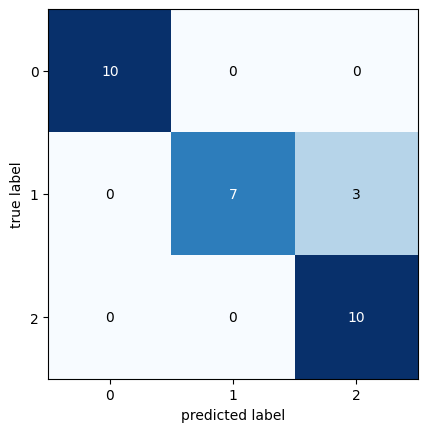

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.70      0.82        10
           2       0.77      1.00      0.87        10

    accuracy                           0.90        30
   macro avg       0.92      0.90      0.90        30
weighted avg       0.92      0.90      0.90        30



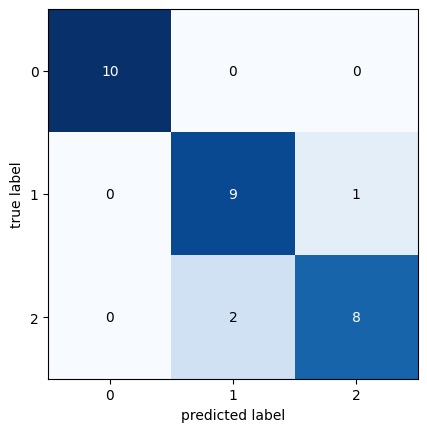

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.82      0.90      0.86        10
           2       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



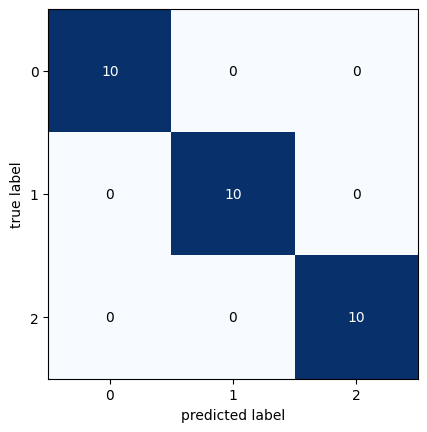

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

0.9816666666666667
0.9533333333333334


In [7]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_val_score
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler, LabelEncoder
from mlxtend.plotting import plot_confusion_matrix
import matplotlib.pyplot as plt

df = pd.read_csv('/kaggle/input/datasets/yasserh/housing-prices-dataset/Housing.csv')

df = pd.get_dummies(df, drop_first=True)

X = df.drop('price', axis=1).values
y = df['price'].values.reshape(-1,1)

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X = scaler_X.fit_transform(X)
y = scaler_y.fit_transform(y).ravel()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

regModel = MLPRegressor(hidden_layer_sizes=(256,128,64,32), activation='relu', solver='adam', max_iter=1000)
regModel.fit(X_train, y_train)

y_pred = regModel.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

kf_reg = KFold(n_splits=5)
cv_scores = cross_val_score(regModel, X, y, cv=kf_reg, scoring='r2')

print(mse)
print(r2)
print(cv_scores.mean())

iris = pd.read_csv('/kaggle/input/datasets/arshid/iris-flower-dataset/IRIS.csv')

X = iris.iloc[:, 1:-1].values
y = iris.iloc[:, -1].values

le = LabelEncoder()
y = le.fit_transform(y)

scaler = StandardScaler()
X = scaler.fit_transform(X)

kf_cls = StratifiedKFold(n_splits=5)

train_acc = []
test_acc = []

for train_index, test_index in kf_cls.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    clsModel = MLPClassifier(hidden_layer_sizes=(34,22), activation='relu', solver='adam', max_iter=1000)
    clsModel.fit(X_train, y_train)
    
    y_train_pred = clsModel.predict(X_train)
    y_test_pred = clsModel.predict(X_test)
    
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    
    train_acc.append(train_accuracy)
    test_acc.append(test_accuracy)
    
    cm = confusion_matrix(y_test, y_test_pred, labels=np.unique(y))
    fig, ax = plot_confusion_matrix(conf_mat=cm)
    plt.show()
    
    print(classification_report(y_test, y_test_pred, zero_division=0))

print(np.mean(train_acc))
print(np.mean(test_acc))